<h1 style="
    text-align: center;
    color: #2E7D32;
    font-family: Georgia;
    font-size: 36px;
    font-weight: bold;
">
   Exploratory Data Analysis of Soil and Environmental Parameters Across Different Crops

<p style="
    text-align: center;
    color: #666;
    font-family: Arial;
    font-size: 16px;
">
    Analyzing Soil and Environmental Parameters for Effective Crop Recommendation
</p>

## Problem Statement - 
### $Understanding$ $how$ $soil$ $nutrients$ $and$ $environmental$ $conditions$ $influence$ $the$ $suitability$ $of$ $different$ $crops$ $through$ $exploratory$ $data$ $analysis$.

In [1]:
# Loding the Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [2]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [5]:
df.shape

(2200, 8)

In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [21]:
df.duplicated().sum()

np.int64(0)

------------------------------------------------------------------------------------------------------------------------------------------------------

## Data Observation - 

In [9]:
df.shape

(2200, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [11]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64

In [15]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

--------------------------------------------------------------------------------------------------------------------------------------------------

## Data Cleaning -

#### Column names -

In [18]:
df.columns = df.columns.str.lower()
df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

#### Missing Values - 

In [19]:
# For checking -

df.isnull().sum()

n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [20]:
# Chacking in percentage -

df.isnull().mean() * 100

n              0.0
p              0.0
k              0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64

In [5]:
# Checking the Duplicates -
df.duplicated().sum()

np.int64(0)

-------------------------------------------------------------------------------------------------------------------------------------------------

### Outlier Detection -

In [2]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [24]:

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)


outlier_df = df[outliers]
print(f"Total outliers found: {outlier_df.shape[0]}")


Total outliers found: 432


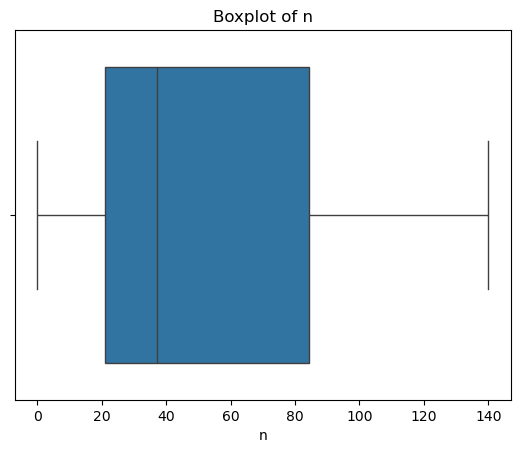

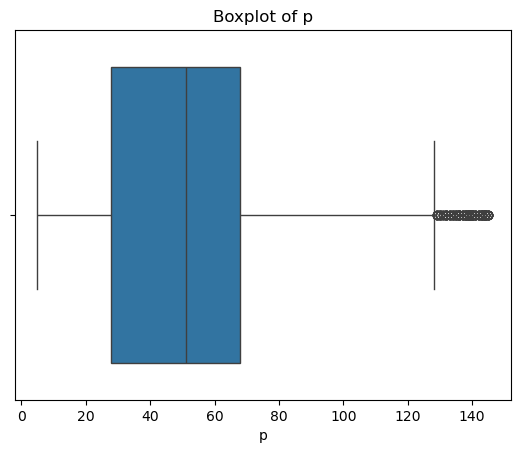

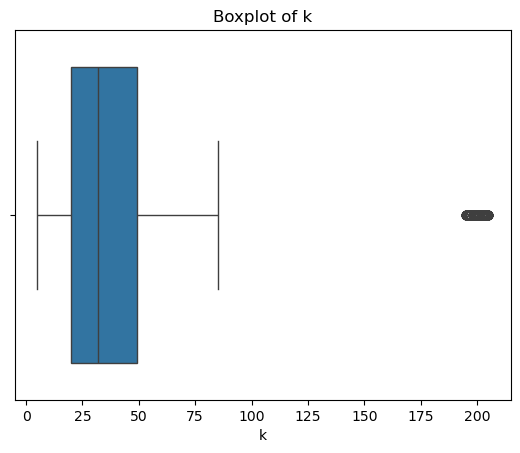

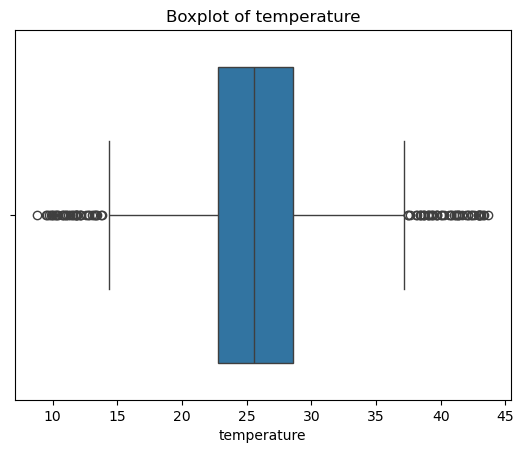

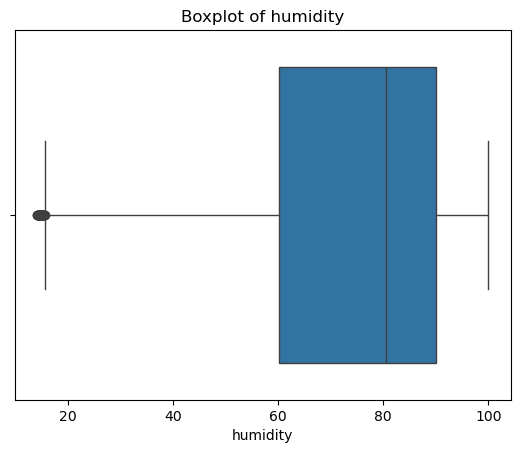

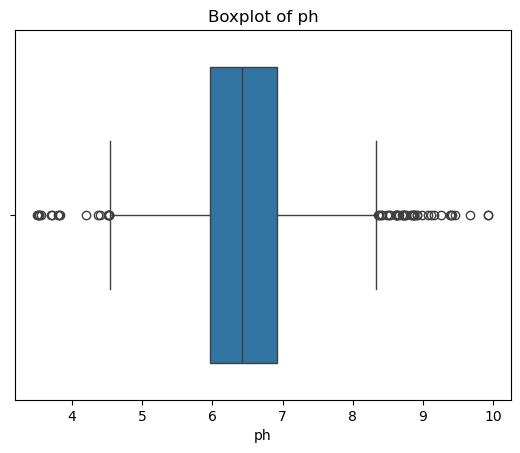

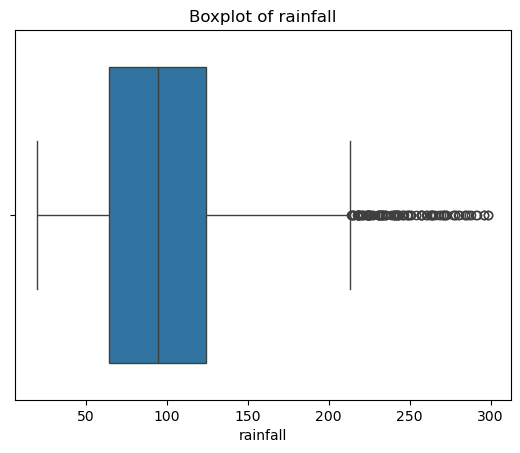

In [26]:
# Let's visulize the outliers - 
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Capping the Outliars -

In [17]:
df_capped = df.copy()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the values
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound,
                              np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col]))

print("Outliers capped successfully!")

Outliers capped successfully!


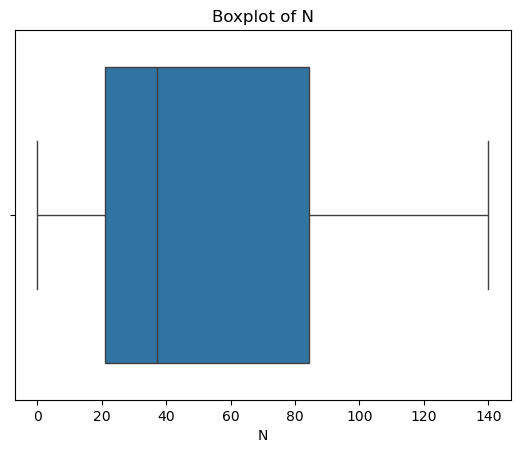

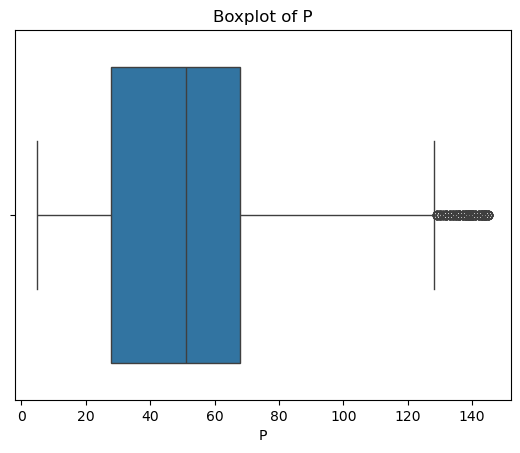

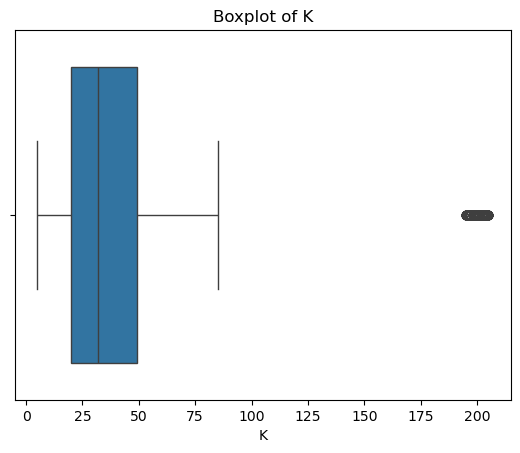

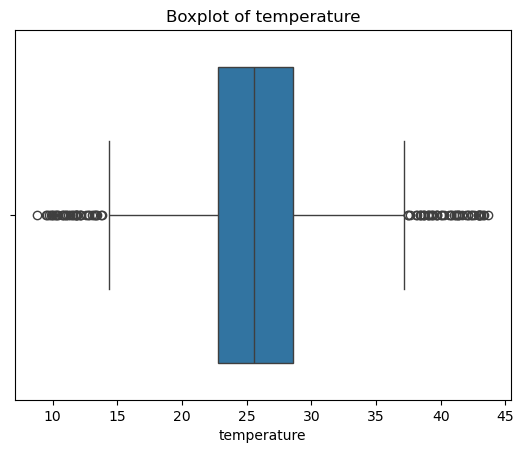

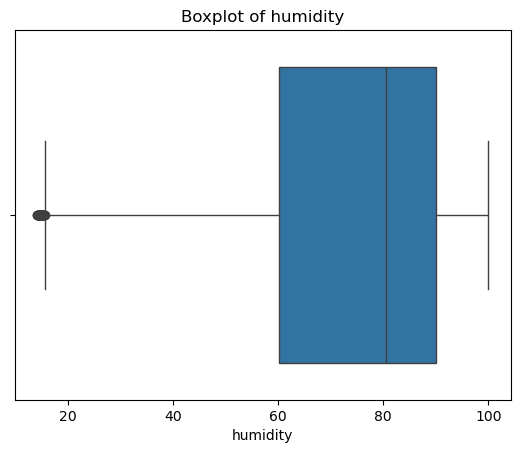

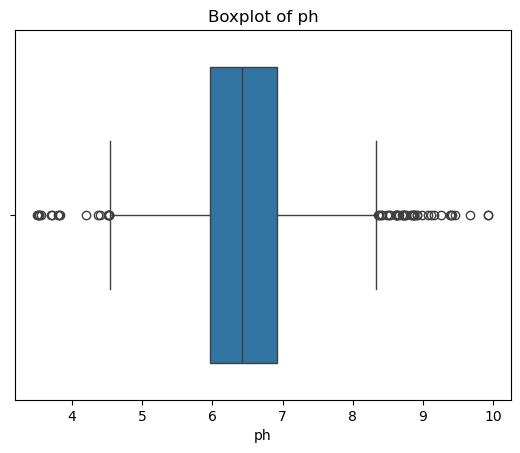

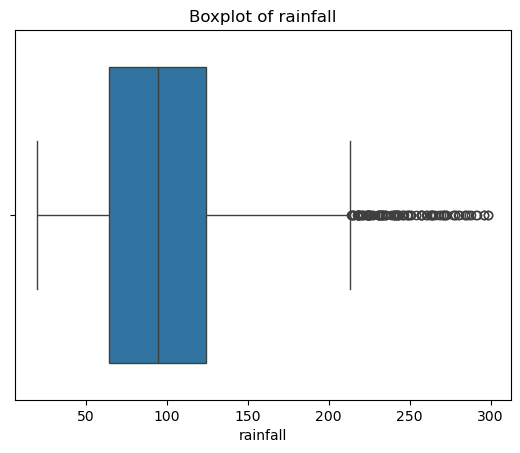

In [18]:
# Let's visulize the outliers - 
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------------

## Class Imbalance

### Target column --> $label$

In [5]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [6]:
df["label"].value_counts(normalize=True) * 100

label
rice           4.545455
maize          4.545455
jute           4.545455
cotton         4.545455
coconut        4.545455
papaya         4.545455
orange         4.545455
apple          4.545455
muskmelon      4.545455
watermelon     4.545455
grapes         4.545455
mango          4.545455
banana         4.545455
pomegranate    4.545455
lentil         4.545455
blackgram      4.545455
mungbean       4.545455
mothbeans      4.545455
pigeonpeas     4.545455
kidneybeans    4.545455
chickpea       4.545455
coffee         4.545455
Name: proportion, dtype: float64

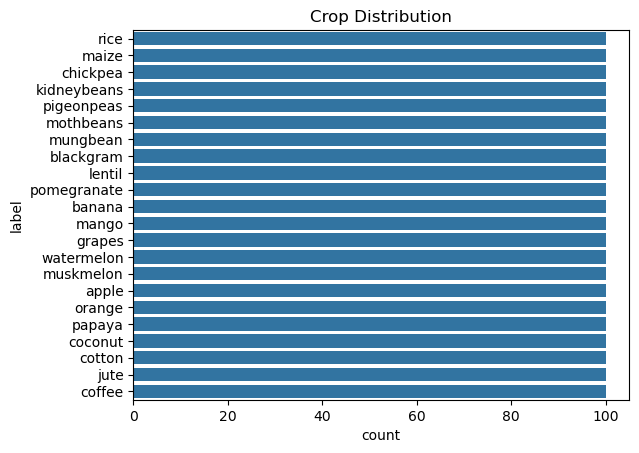

In [7]:
# Visulization -

sns.countplot(data=df, y="label")
plt.title("Crop Distribution")
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------

## Data Visulization and Analysis -

In [8]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


## 1. Univariate Analysis -

### Univariate Analysis of `"column - N (Nitrogen)"` -

In [28]:
df["N"].describe()

count    2200.000000
mean       50.551818
std        36.917334
min         0.000000
25%        21.000000
50%        37.000000
75%        84.250000
max       140.000000
Name: N, dtype: float64

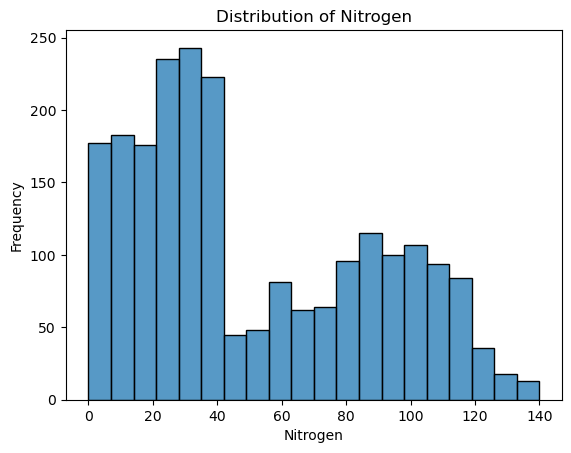

In [12]:
# Visulization 1 - "Histogram"

sns.histplot(data=df, x="N", bins=20)

plt.title("Distribution of Nitrogen")
plt.xlabel("Nitrogen")
plt.ylabel("Frequency")

plt.show()

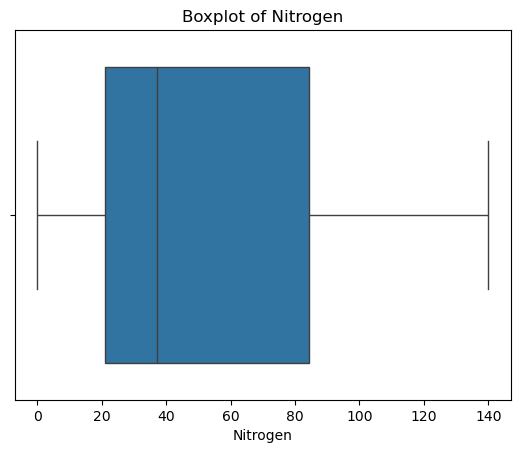

In [14]:
# Visulization 2 - 

sns.boxplot(x=df["N"])

plt.title("Boxplot of Nitrogen")
plt.xlabel("Nitrogen")

plt.show()

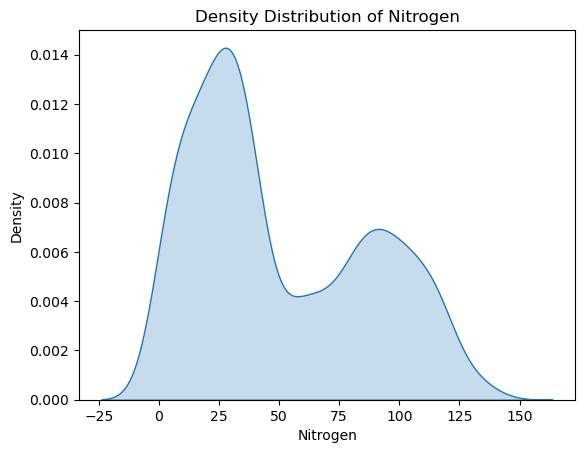

In [15]:
# Visulization 3 - 

sns.kdeplot(data=df, x="N", fill=True)

plt.title("Density Distribution of Nitrogen")
plt.xlabel("Nitrogen")

plt.show()

###  Univariate Analysis of `"column - P (Phosphorus)"`

In [16]:
df["P"].describe()

count    2200.000000
mean       53.362727
std        32.985883
min         5.000000
25%        28.000000
50%        51.000000
75%        68.000000
max       145.000000
Name: P, dtype: float64

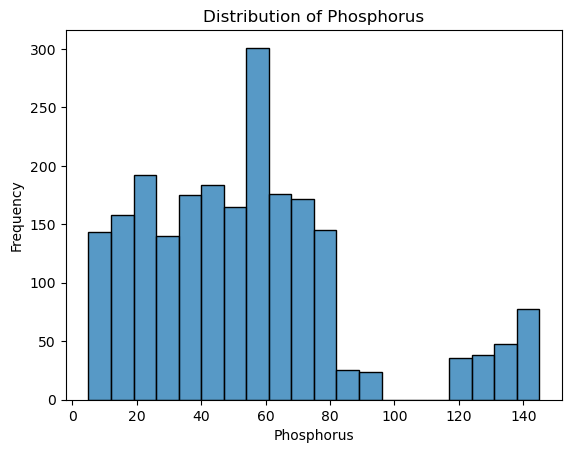

In [19]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="P", bins=20)

plt.title("Distribution of Phosphorus")
plt.xlabel("Phosphorus")
plt.ylabel("Frequency")

plt.show()

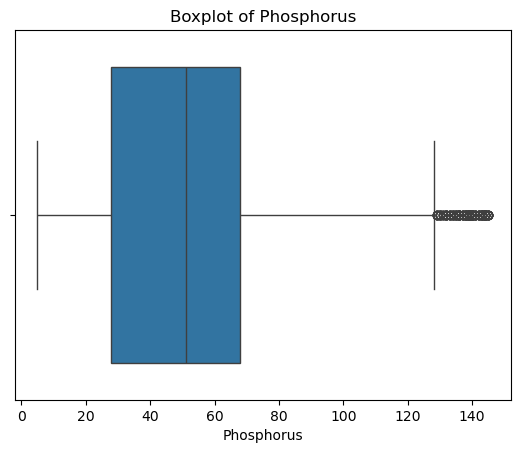

In [21]:
# Visulization 2 - (Boxplot)

sns.boxplot(x=df["P"])

plt.title("Boxplot of Phosphorus")
plt.xlabel("Phosphorus")

plt.show()

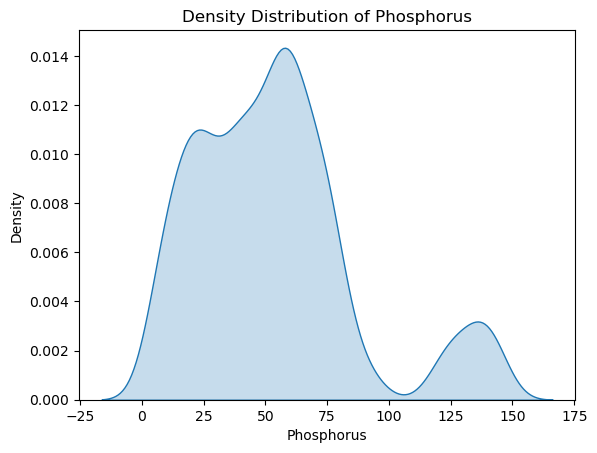

In [26]:
# Visulization 3 - (KDE Plot)

sns.kdeplot(data=df, x="P", fill=True)

plt.title("Density Distribution of Phosphorus")
plt.xlabel("Phosphorus")

plt.show()

### Univariate Analysis of `"column - K (Potassium)"` -

In [22]:
df["K"].describe()

count    2200.000000
mean       48.149091
std        50.647931
min         5.000000
25%        20.000000
50%        32.000000
75%        49.000000
max       205.000000
Name: K, dtype: float64

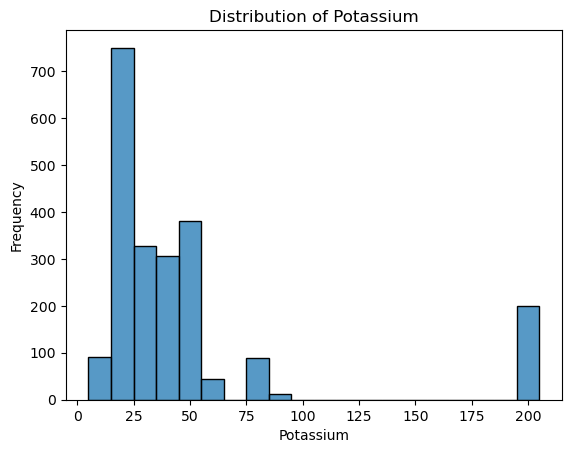

In [23]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="K", bins=20)

plt.title("Distribution of Potassium")
plt.xlabel("Potassium")
plt.ylabel("Frequency")

plt.show()

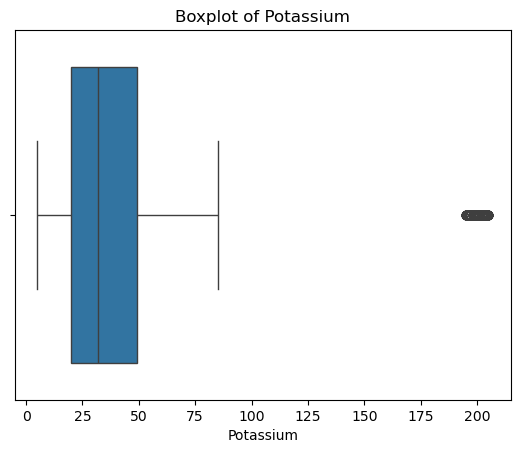

In [24]:
# Visulization 2 - (Boxplot)

sns.boxplot(x=df["K"])

plt.title("Boxplot of Potassium")
plt.xlabel("Potassium")

plt.show()

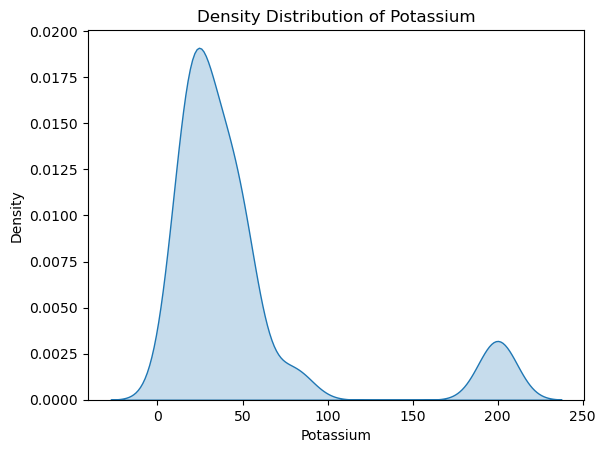

In [27]:
# Visuization 3 - (KDE Plot)

sns.kdeplot(data=df, x="K", fill=True)

plt.title("Density Distribution of Potassium")
plt.xlabel("Potassium")

plt.show()

### Univariate Analysis of `"column - temperature"` -

In [30]:
df["temperature"].describe()

count    2200.000000
mean       25.616244
std         5.063749
min         8.825675
25%        22.769375
50%        25.598693
75%        28.561654
max        43.675493
Name: temperature, dtype: float64

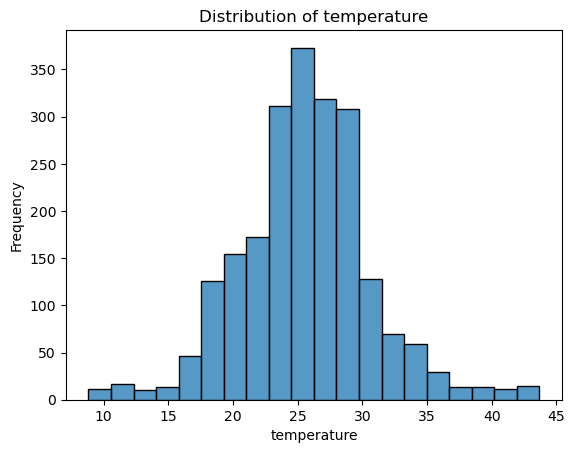

In [32]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="temperature", bins=20)

plt.title("Distribution of temperature")
plt.xlabel("temperature")
plt.ylabel("Frequency")

plt.show()

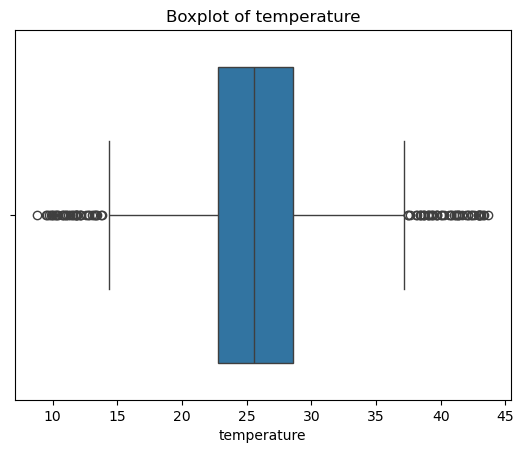

In [33]:
# Visulization 2 - (Boxplot)

sns.boxplot(x=df["temperature"])

plt.title("Boxplot of temperature")
plt.xlabel("temperature")

plt.show()

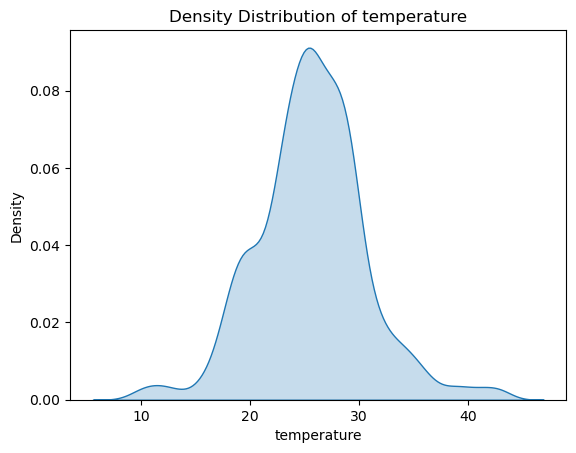

In [35]:
# Visulization 3 - (KDE plot)

sns.kdeplot(data=df, x="temperature", fill=True)

plt.title("Density Distribution of temperature")
plt.xlabel("temperature")

plt.show()

### Univariate Analysis of `"column - humidity"`

In [ ]:
df["humidity"].describe()

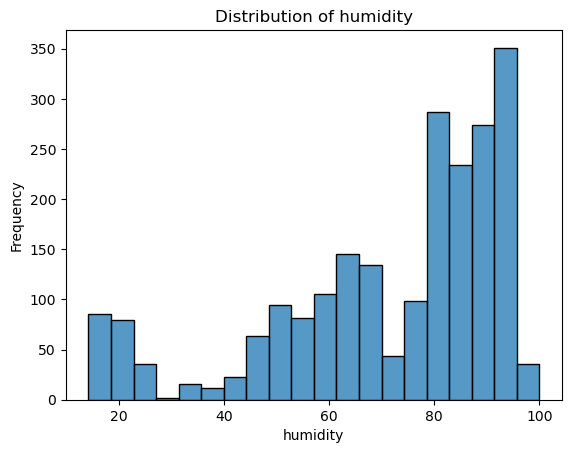

In [36]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="humidity", bins=20)

plt.title("Distribution of humidity")
plt.xlabel("humidity")
plt.ylabel("Frequency")

plt.show()

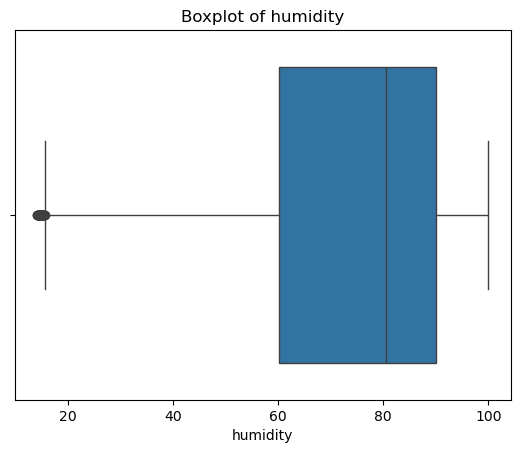

In [37]:
# Visulization 2 - (Boxplot)

sns.boxplot(x=df["humidity"])

plt.title("Boxplot of humidity")
plt.xlabel("humidity")

plt.show()

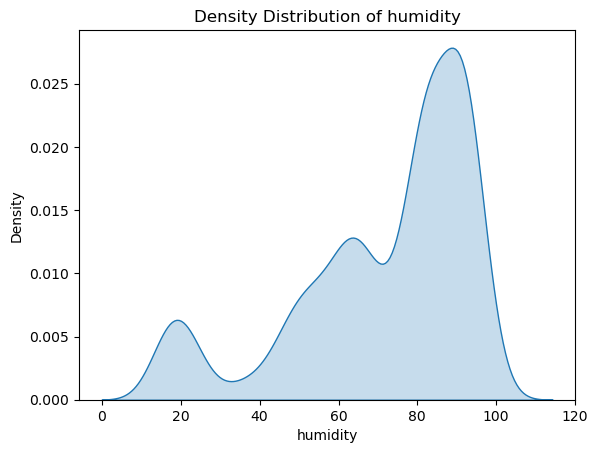

In [38]:
# Visulization 3 - (KDE plot)

sns.kdeplot(data=df, x="humidity", fill=True)

plt.title("Density Distribution of humidity")
plt.xlabel("humidity")

plt.show()

### Univariate Analysis of `"column - ph"`

In [39]:
df["ph"].describe()

count    2200.000000
mean        6.469480
std         0.773938
min         3.504752
25%         5.971693
50%         6.425045
75%         6.923643
max         9.935091
Name: ph, dtype: float64

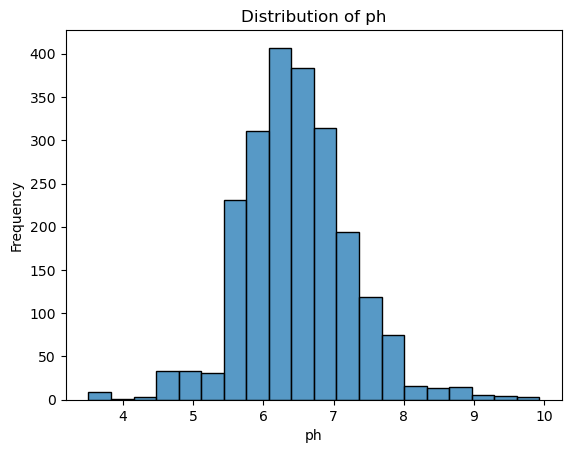

In [12]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="ph", bins=20)

plt.title("Distribution of ph")
plt.xlabel("ph")
plt.ylabel("Frequency")

plt.show()

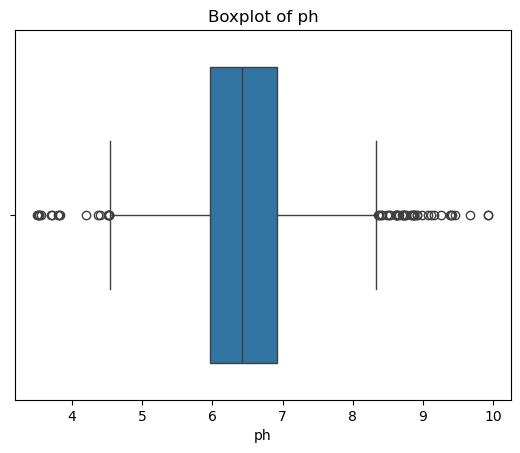

In [42]:
# Visulization 2 - (Boxplot)

sns.boxplot(x=df["ph"])

plt.title("Boxplot of ph")
plt.xlabel("ph")

plt.show()

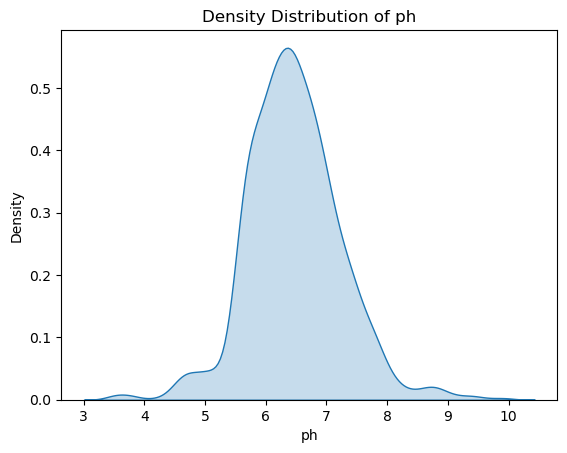

In [11]:
# Visulization 3 - (KDE plot)

sns.kdeplot(data=df, x="ph", fill=True)

plt.title("Density Distribution of ph")
plt.xlabel("ph")

plt.show()

### Univariate Analysis of `"column - rainfall"` -

In [44]:
df["rainfall"].describe()

count    2200.000000
mean      103.463655
std        54.958389
min        20.211267
25%        64.551686
50%        94.867624
75%       124.267508
max       298.560117
Name: rainfall, dtype: float64

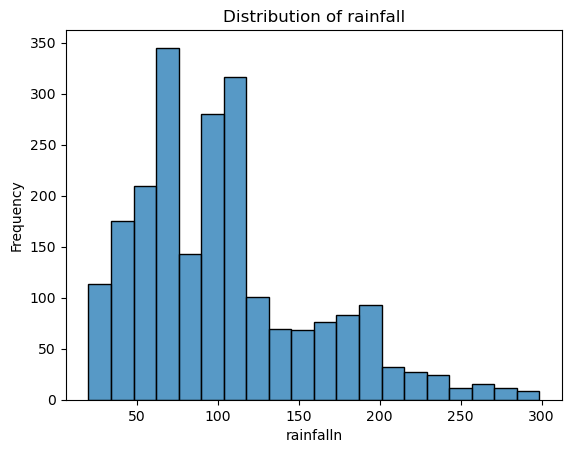

In [45]:
# Visulization 1 - (Histogram)

sns.histplot(data=df, x="rainfall", bins=20)

plt.title("Distribution of rainfall")
plt.xlabel("rainfalln")
plt.ylabel("Frequency")

plt.show()

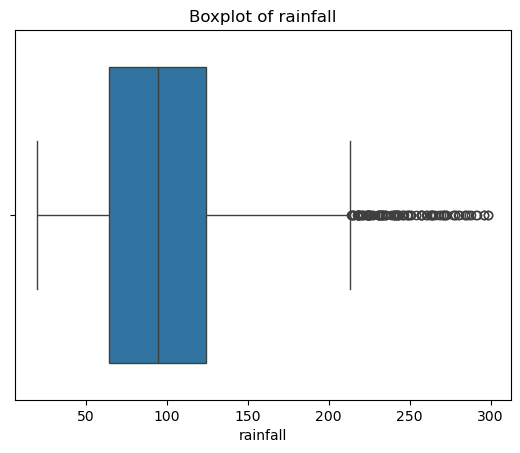

In [46]:
#Visulization 2 - (Boxplot)

sns.boxplot(x=df["rainfall"])

plt.title("Boxplot of rainfall")
plt.xlabel("rainfall")

plt.show()

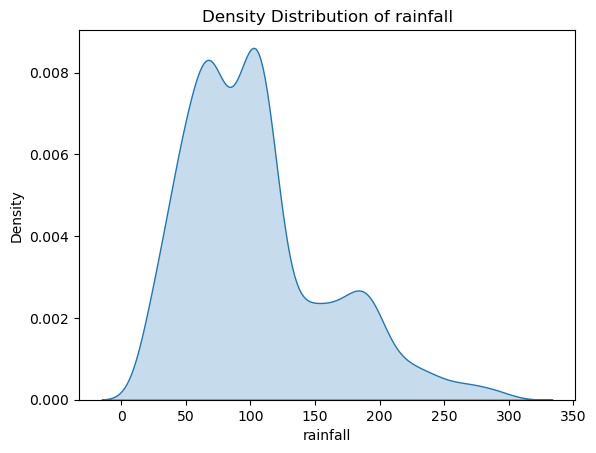

In [47]:
sns.kdeplot(data=df, x="rainfall", fill=True)

plt.title("Density Distribution of rainfall")
plt.xlabel("rainfall")

plt.show()

### The final visulization (Bar chart) - 

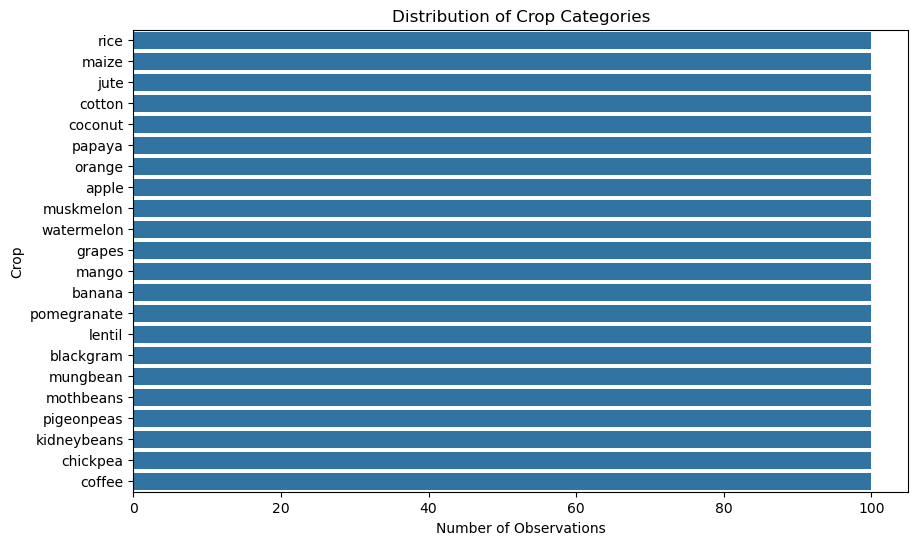

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="label",
    order=df["label"].value_counts().index
)

plt.title("Distribution of Crop Categories")
plt.xlabel("Number of Observations")
plt.ylabel("Crop")

plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------

## 2. Bivariate Analysis -

In [3]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


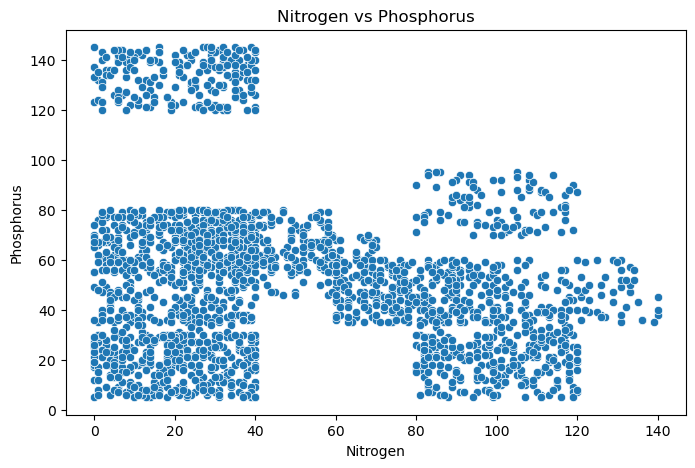

Correlation: -0.23145957738457212


In [10]:
# 1. Nitrogen vs Phosphorus  (Scatter plot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="N", y="P")
plt.title("Nitrogen vs Phosphorus")
plt.xlabel("Nitrogen")
plt.ylabel("Phosphorus")
plt.show()

print("Correlation:", df["N"].corr(df["P"]))

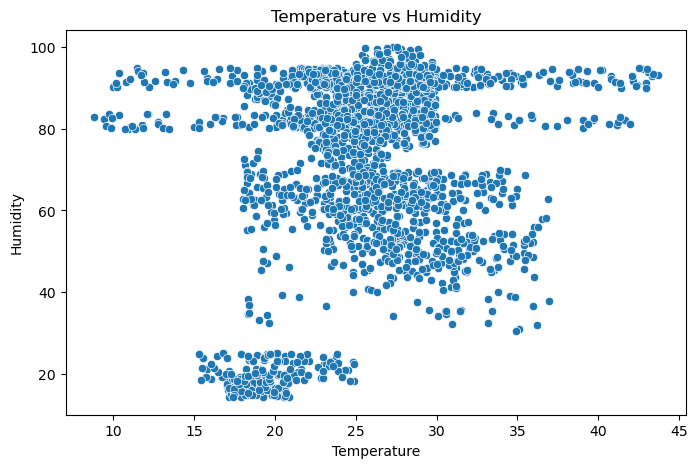

Correlation: 0.20531967663070338


In [11]:
# 2. Temperature vs Humidity  (Scatter plot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="temperature", y="humidity")
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

print(
    "Correlation:",
    df["temperature"].corr(df["humidity"])
)

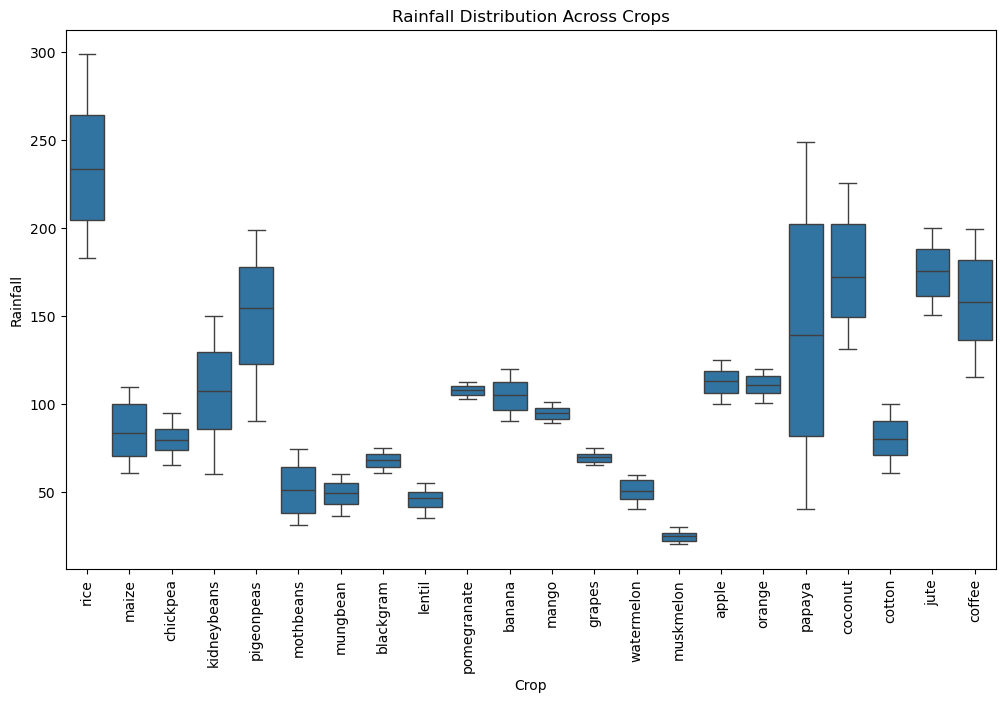

In [12]:
# 3. Rainfall vs Crop  (Box plot)
plt.figure(figsize=(12,7))
sns.boxplot(data=df, x="label", y="rainfall")
plt.title("Rainfall Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("Rainfall")
plt.xticks(rotation=90)
plt.show()


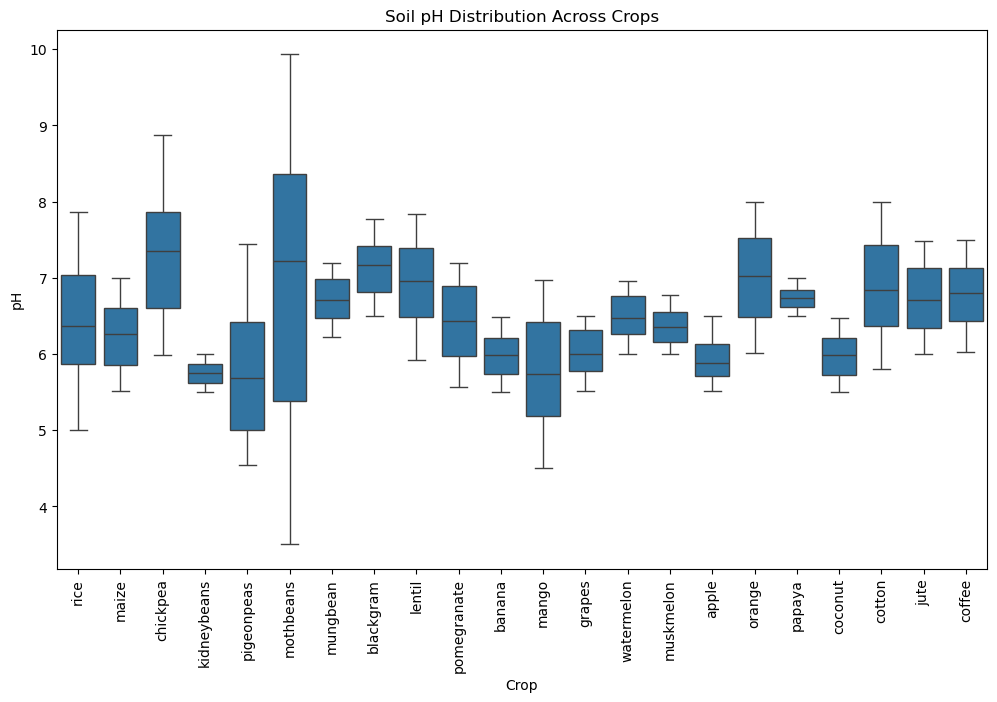

In [13]:
# 4. pH vs Crop     (Boxplot)
plt.figure(figsize=(12,7))
sns.boxplot(data=df, x="label", y="ph")
plt.title("Soil pH Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("pH")
plt.xticks(rotation=90)
plt.show()

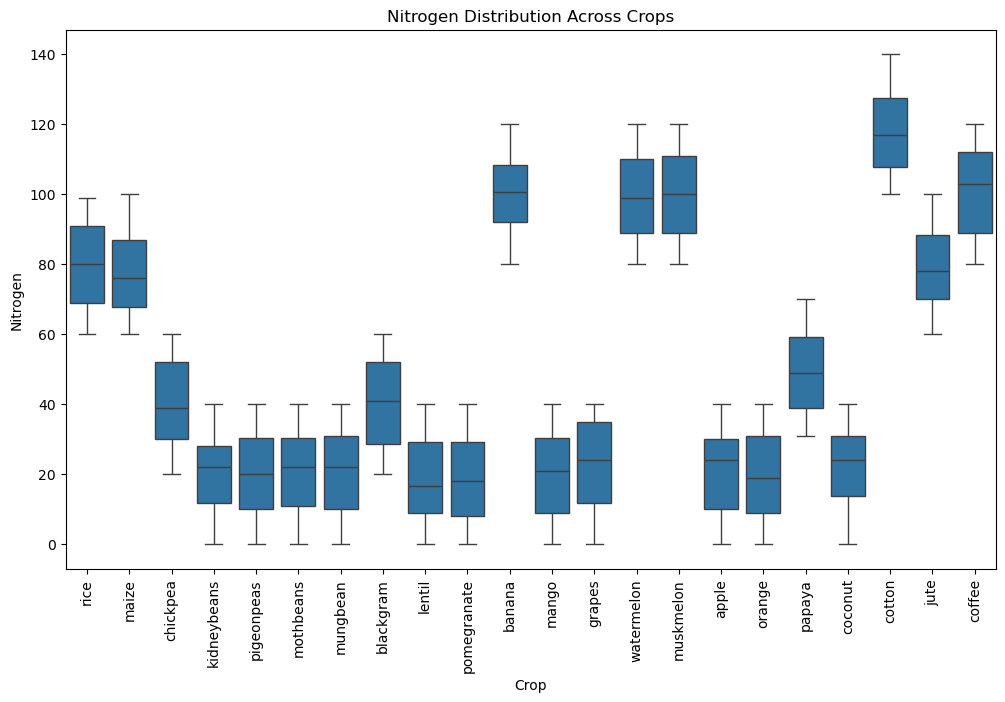

In [14]:
# 5. Nitrogen vs Crop   (Boxplot)
plt.figure(figsize=(12,7))
sns.boxplot(data=df, x="label", y="N")
plt.title("Nitrogen Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("Nitrogen")
plt.xticks(rotation=90)
plt.show()


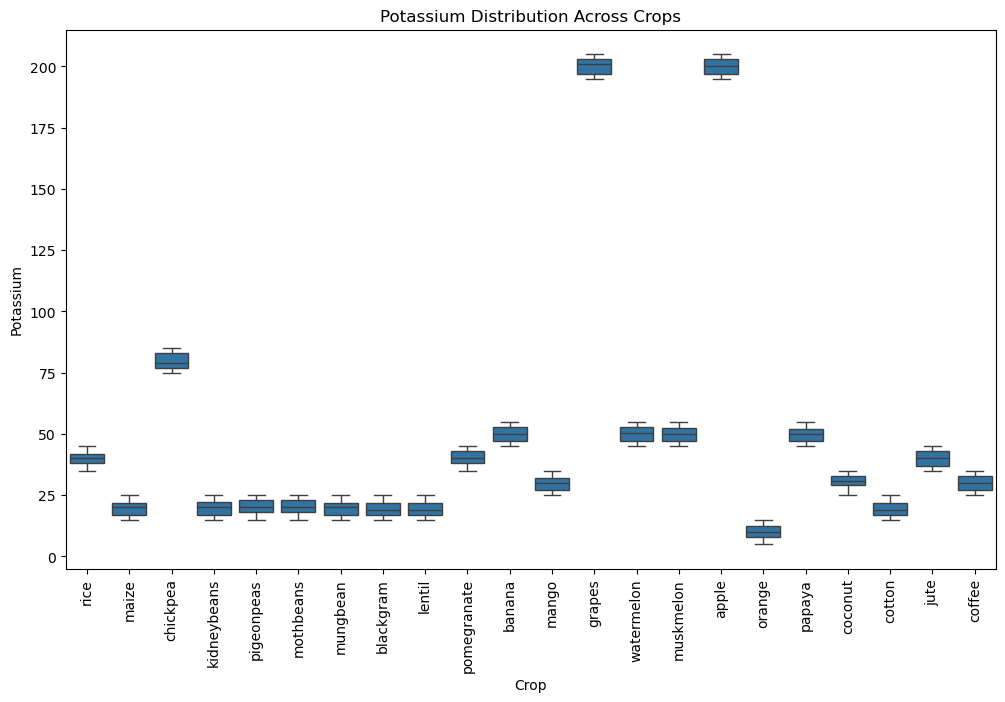

In [15]:
# 6. Potassium vs Crop    (Boxplot)
plt.figure(figsize=(12,7))
sns.boxplot(data=df, x="label", y="K")
plt.title("Potassium Distribution Across Crops")
plt.xlabel("Crop")
plt.ylabel("Potassium")
plt.xticks(rotation=90)
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------------------

## 3. Multivariate Analysis -

In [3]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


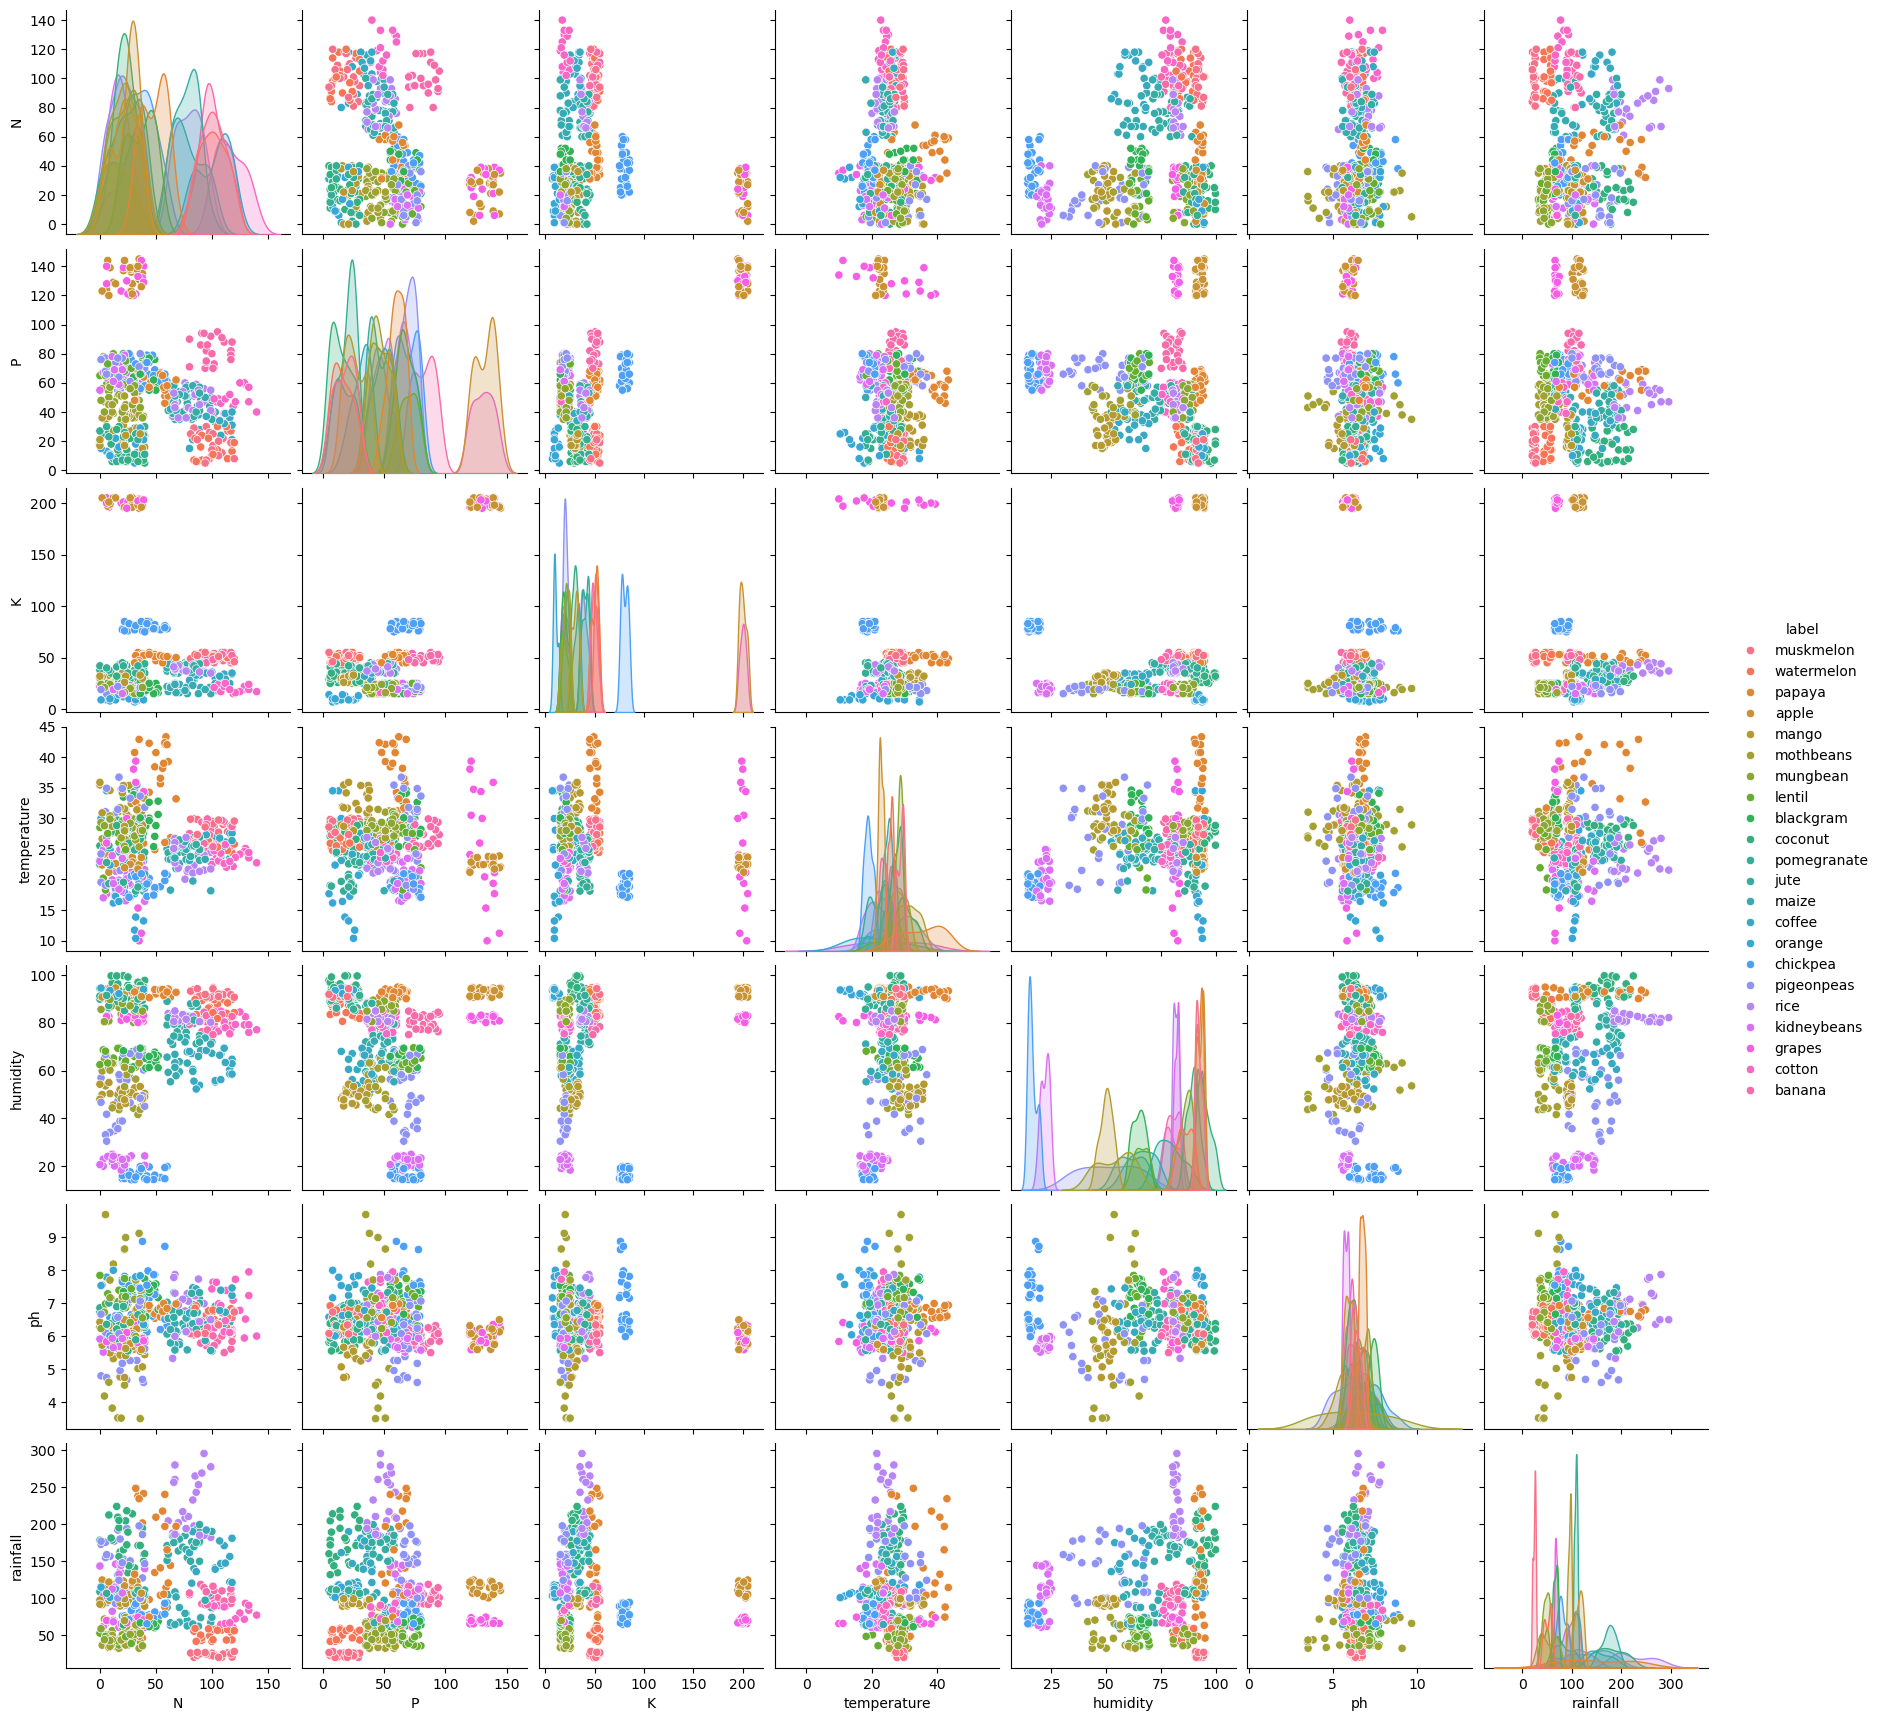

In [4]:
sample_df = df.sample(500, random_state=42)

sns.pairplot(
    sample_df,
    hue='label'
)

plt.show()

In [4]:
numeric_cols = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

correlation_matrix = df[numeric_cols].corr()

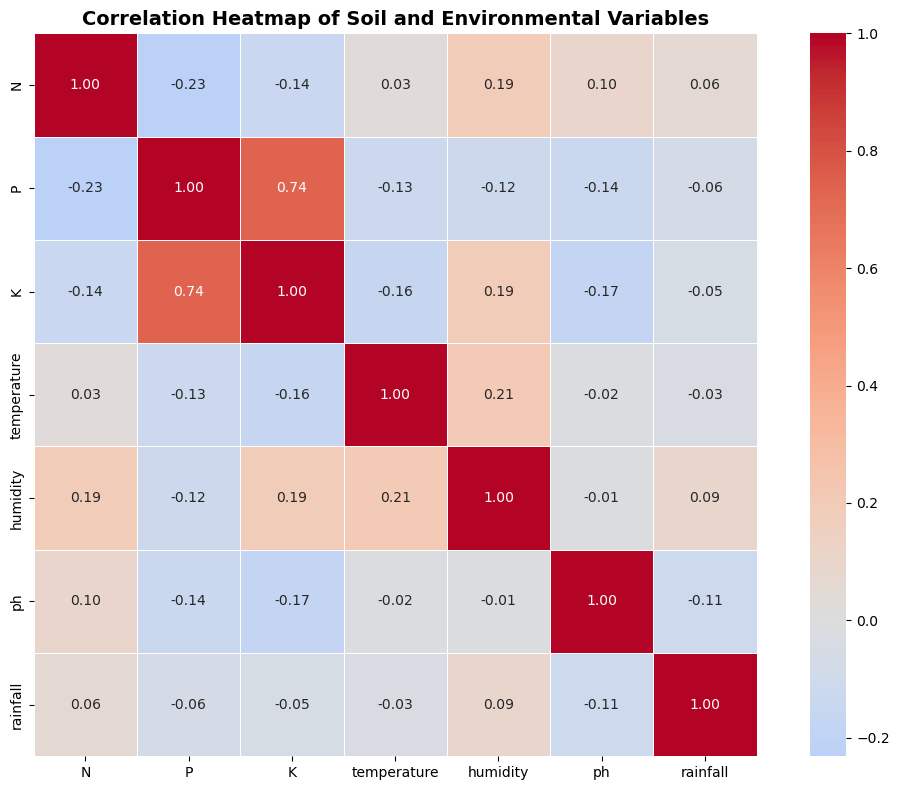

In [5]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Soil and Environmental Variables',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------

## 3 Variable Relationship -

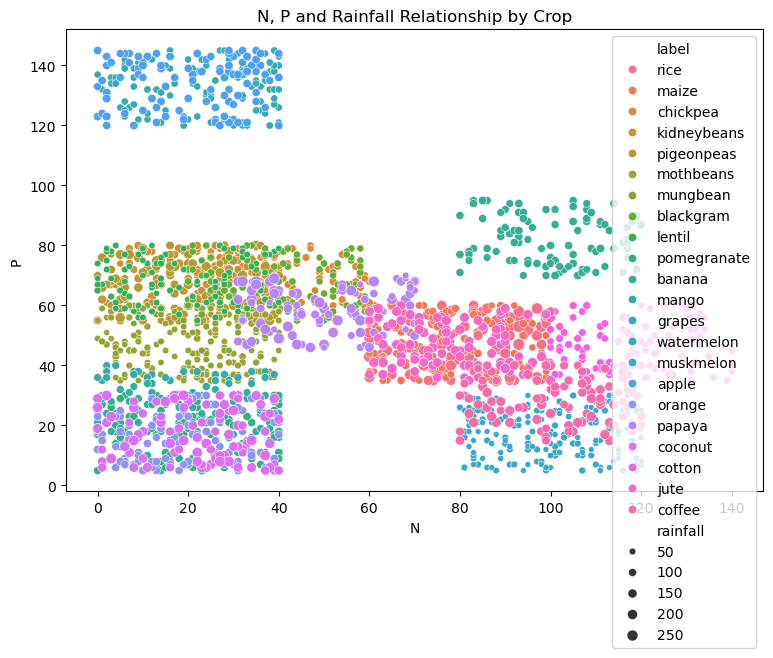

In [6]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='N',
    y='P',
    size='rainfall',
    hue='label'
)

plt.title("N, P and Rainfall Relationship by Crop")

plt.show()

----------------------------------------------------------------------------------------------------------------------------------------

## Pivot Tables -

### 1. Average nutrients by crop:

In [7]:
pivot1 = pd.pivot_table(
    df,
    values=['N','P','K'],
    index='label',
    aggfunc='mean'
)

pivot1

,K,N,P
label,,,
apple,199.89,20.80,134.22
banana,50.05,100.23,82.01
blackgram,19.24,40.02,67.47
chickpea,79.92,40.09,67.79
coconut,30.59,21.98,16.93
coffee,29.94,101.20,28.74
cotton,19.56,117.77,46.24
grapes,200.11,23.18,132.53
jute,39.99,78.40,46.86


### 2. Environmental conditions:

In [8]:
pivot2 = pd.pivot_table(
    df,
    values=['temperature','humidity',
            'ph','rainfall'],
    index='label',
    aggfunc='mean'
)

pivot2

,humidity,ph,rainfall,temperature
label,,,,
apple,92.333383,5.929663,112.654779,22.630942
banana,80.358123,5.983893,104.626980,27.376798
blackgram,65.118426,7.133952,67.884151,29.973340
chickpea,16.860439,7.336957,80.058977,18.872847
coconut,94.844272,5.976562,175.686646,27.409892
coffee,58.869846,6.790308,158.066295,25.540477
cotton,79.843474,6.912675,80.398043,23.988958
grapes,81.875228,6.025937,69.611829,23.849575
jute,79.639864,6.732778,174.792798,24.958376


-----------------------------------------------------------------------------------------------------------------------------------------

## Key Insights -

### Insight 1

Some crops may show substantially different nutrient requirements.

### Insight 2

Certain crops may be associated with higher rainfall conditions.

### Insight 3

Some crops may prefer higher humidity.

### Insight 4

Crop groups may form visible clusters based on environmental conditions.

### Insight 5

Some nutrient variables may have stronger correlations with each other than others.

### Insight 6

pH ranges can reveal whether particular crops tend to occur in acidic, neutral or alkaline conditions.


<h1 style="
    text-align: center;
    color: #FF7F50;
    font-family: Georgia;
    font-size: 36px;
    font-weight: bold;
">
    Thank You!!!